In [226]:
import torch
import torch.optim as optim
from torchviz import make_dot
import pandas as pd
from itables import init_notebook_mode, show
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import importlib
from tqdm import tqdm

import aacbr

init_notebook_mode(all_interactive=True)

In [227]:
def reload_imports():
    importlib.reload(aacbr)

## Gradual AACBR

In [228]:
# Deep Arguing?
class GradualAACBR(torch.nn.Module):

    def __init__(self, no_features):
        super(GradualAACBR, self).__init__()
        # n = no.nodes
        # f = no.features
        # TODO: Consider other methods of initialising weights
        self.W = torch.nn.Parameter(torch.Tensor(no_features))
        torch.nn.init.normal_(self.W)
    
    def compute_base_scores(self, nodes):
        # TODO: Base Scores must be between 0 and 1 - using sigmoid for now 
        base_scores = torch.sigmoid(torch.matmul(nodes, self.W))
        return base_scores


    def forward(self, nodes, A, new_cases_attacks, max_iters = 5):


        # TODO: new_case should do one of:
        #   CURRENT: set base scores of any that it attacks to 0 -> i.e. irrelevant arguments have no strength 
        #   POSSIBLE: compute it's base strength and use that + attacks to influence what it attacks 

        if new_cases_attacks.dim() == 1:
            new_cases_attacks = new_cases_attacks.unsqueeze(dim=0)

        batch_size = new_cases_attacks.shape[0]
        base_scores = self.compute_base_scores(nodes) # (n)
        base_scores = torch.tile(base_scores.unsqueeze(dim=0), (batch_size, 1)) # (B x n)
        base_scores = torch.where(new_cases_attacks, 1e-6, base_scores) # TODO: Change how this handled
        base_scores = base_scores.unsqueeze(2) # (B x n x 1)

        strengths = [base_scores]
        base_score_influence = torch.log(base_scores/(1-base_scores))
        
        # TODO: change to use one of the following stop conditions:
        #   (convergence under some epsilon or max iters reached) OR 
        #   sort the nodes topologically and figure out how to do a single pass with matrix operations -> Only works for ACYCLIC graphs 
        for i in range(max_iters):
            # TODO: Take aggregation/influence functions as parameters of the class
            # to decouple the model from any one semantic
            aggregations = torch.matmul(A.T, strengths[i]) # (incoming edges linear combination with strengths of node) -> n 
            influences = torch.sigmoid(base_score_influence  + aggregations)
            strengths.append(influences)

        final_strengths = strengths[-1].squeeze()
        if final_strengths.dim() == 1:
            final_strengths = final_strengths.unsqueeze(0)
        
        return final_strengths





In [229]:
reload_imports()

torch.manual_seed(42)
nodes = torch.rand((4, 5))
nodes[0] = nodes[0] * 0 # Default case has values set to 0 so base_score is computed as 0.5
A = torch.tensor([
                #     0   1   2   3
                    [ 0,  0,  0,  0], # 0
                    [-1,  0,  0,  0], # 1
                    [-1,  0,  0,  0], # 2
                    [ 0, -1,  0,  0], # 3
                ], dtype=torch.float32)

model = GradualAACBR(5)
result = model(nodes=nodes, A=A, new_cases_attacks=torch.tensor([True, False, True, True]), max_iters=3)
print(result)
make_dot(result, params=dict(model.named_parameters())).render("attached", format="png")

tensor([[6.5519e-07, 4.2283e-01, 1.0000e-06, 1.0000e-06]],
       grad_fn=<UnsqueezeBackward0>)


'attached.png'

## Data Set

In [230]:
SEED = 42

In [231]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# data (as pandas dataframes) 
X = connectionist_bench_sonar_mines_vs_rocks.data.features 
y = connectionist_bench_sonar_mines_vs_rocks.data.targets 
X = X.values

# show(X)
# print(y.nunique())



In [232]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)


/home/adamg/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/adamg/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


## Train Model

In [233]:

# Once W is learned, create a new graph with training + validation set and test performance on the test set 


### Split into Training, Validation and Test

In [234]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")

Test Size:  42
Train Size:  132
Validation Size:  34


In [235]:
print(X_train)

[[0.026  0.0363 0.0136 ... 0.0036 0.0061 0.0115]
 [0.0368 0.0403 0.0317 ... 0.0067 0.0078 0.0068]
 [0.009  0.0062 0.0253 ... 0.0053 0.0189 0.0102]
 ...
 [0.0423 0.0321 0.0709 ... 0.0021 0.0043 0.0017]
 [0.01   0.0194 0.0155 ... 0.0019 0.0053 0.0019]
 [0.0293 0.0378 0.0257 ... 0.0055 0.005  0.0087]]


### Build AF

In [236]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 2

def binarise_by_normal(case):
    return np.where(np.abs(case - means) <= STD_PARAM*std, 0, 1)


def strictsuperset(a, b):

    if b.ndim == 1:
        b = np.expand_dims(b, axis = 0)

    anb = a & b
    return np.logical_and(np.all(anb == b, axis = -1), np.logical_not(np.all(anb == a, axis = -1)))


In [237]:
COMPARISON_FUNC = strictsuperset
PREPROCESS_FUNC = binarise_by_normal 

In [238]:
def plot_weights(model):
    weights = model.W.detach().numpy()
    plt.figure(figsize=(20, 5))
    plt.bar(range(len(weights)), weights)
    for i, value in enumerate(weights):
        plt.text(i, value + (0.1 * (-1 if value <= 0 else 1)), str(round(value, 3)), ha='center', fontsize=6)
    plt.xlabel('Features')
    plt.ylabel('Weights')
    plt.title('Feature Attribution Weights')
    plt.show()

### Train Model

In [239]:
DEFAULT_OUTCOME = 1
DEFAULT_CASE = means.copy()
MAX_ITERS = 10 
EPOCHS = 75 
N_SPLITS = 5

In [240]:
torch.manual_seed(0) # TRY DIFFERENT INITIAL WEIGHTS 
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
model = GradualAACBR(X_train.shape[1])
criterion = torch.nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

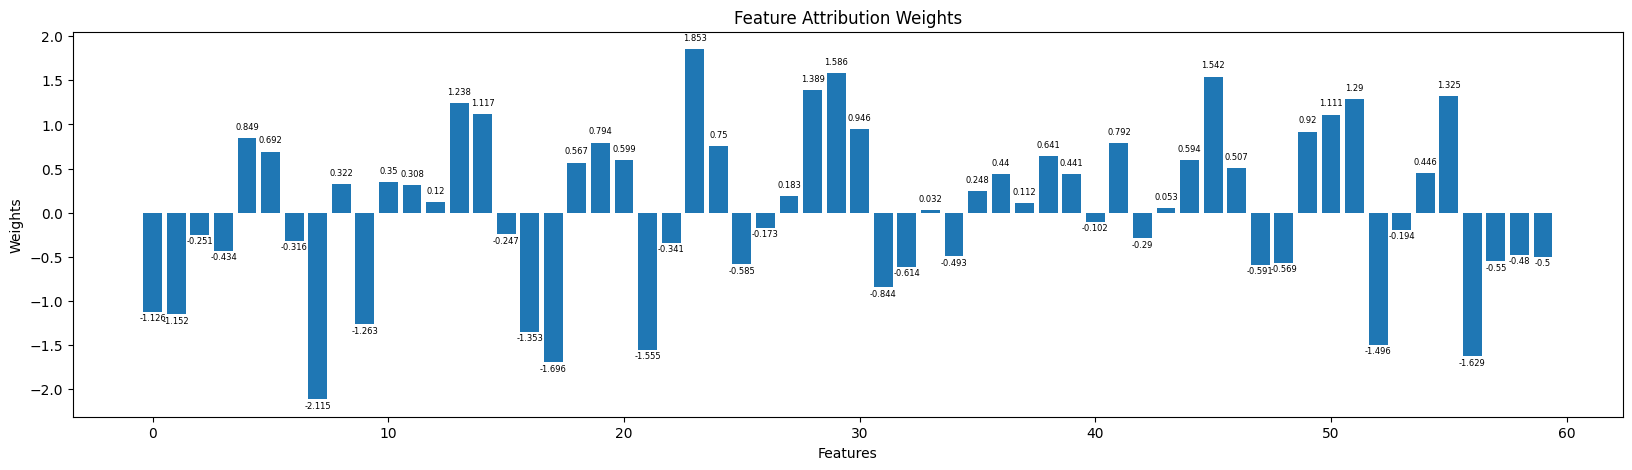

In [241]:
# Visulaise Feature weights before training
plot_weights(model)

In [242]:
reload_imports()
def build_aacbr(casebase, casebase_labels):

    aacbr_model = aacbr.AACBR(
        PREPROCESS_FUNC(casebase), 
        casebase_labels, 
        COMPARISON_FUNC, 
        PREPROCESS_FUNC(DEFAULT_CASE), 
        DEFAULT_OUTCOME,
        build_parallel=True
    )

    default_index = aacbr_model.default_index

    casebase_tensor = torch.zeros((casebase.shape[0] + 1, casebase.shape[1]))
    casebase_tensor[:default_index, :] = torch.tensor(casebase)
    # TODO: Need to handle default better - maybe should have a base score of
    # near 1 - cannot be exactly 1 as MLP semantics do not update if set to 0 or 1
    casebase_tensor[default_index, :] = torch.tensor(DEFAULT_CASE)  
    A = torch.tensor(aacbr_model.A, dtype=torch.float32)


    return casebase_tensor, A, default_index, aacbr_model

def run_gradual_model(gradual_model, aacbr_model, casebase_tensor, A, new_cases):

    new_cases_attacks = torch.tensor(
        aacbr_model.get_new_case_attacks_mask(PREPROCESS_FUNC(new_cases))
    )
    return gradual_model(casebase_tensor, A, new_cases_attacks, max_iters=MAX_ITERS)

def evaluate_model(casebase, casebase_labels, new_cases, new_cases_labels, show_confusion=False):
    casebase_tensor, A, default_index, aacbr_model = build_aacbr(casebase, casebase_labels)
    final_stengths = run_gradual_model(model, aacbr_model, casebase_tensor, A, new_cases)
    predicted = final_stengths[:, default_index].detach().numpy()
    predicted = np.where(predicted > 0.5, 1, 0)

    print("Accuracy, Precision, Recall, F1")
    print([
        accuracy_score(new_cases_labels, predicted),
        precision_score(new_cases_labels, predicted),
        recall_score(new_cases_labels, predicted),
        f1_score(new_cases_labels, predicted)
    ])
    if show_confusion:
        cm = confusion_matrix(new_cases_labels, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()



Accuracy, Precision, Recall, F1
[0.5294117647058824, 0.53125, 0.9444444444444444, 0.68]


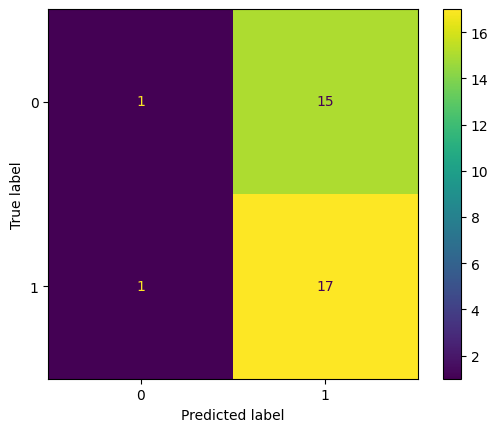

In [243]:
with torch.no_grad():
    evaluate_model(X_train, y_train, X_val, y_val, show_confusion=True)

Fold: 0


Epoch 75, Loss: 0.0238: 100%|██████████| 75/75 [00:00<00:00, 139.03it/s]


Fold: 1


Epoch 75, Loss: 0.0243: 100%|██████████| 75/75 [00:00<00:00, 154.33it/s]


Fold: 2


...

Fold: 3


Epoch 75, Loss: 0.0192: 100%|██████████| 75/75 [00:00<00:00, 140.40it/s]


Fold: 4


Epoch 75, Loss: 0.0205: 100%|██████████| 75/75 [00:00<00:00, 132.18it/s]


Finished Training


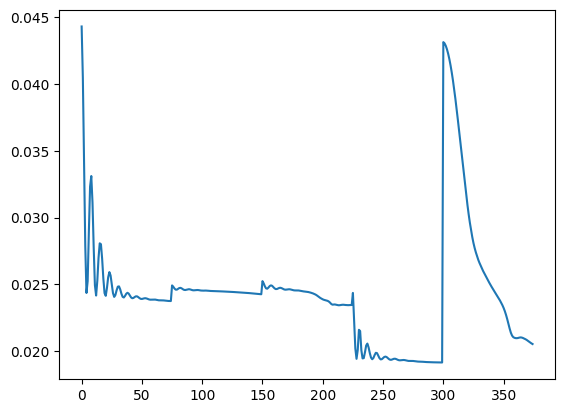

In [244]:
reload_imports()
model.train()
losses = []
for fold, (casebase_index,  new_cases_index) in enumerate(kf.split(X_train)):

    print("Fold:", fold)

    casebase = X_train[casebase_index]
    casebase_labels = y_train[casebase_index]

    new_cases = X_train[new_cases_index]
    new_cases_labels = y_train[new_cases_index]

    casebase_tensor, A, default_index, aacbr_model = build_aacbr(casebase, casebase_labels)
    new_cases_labels = torch.tensor(new_cases_labels, dtype=torch.float32)

    pbar = tqdm(range(EPOCHS))

    for epoch in pbar:  

        running_loss = 0.0
        optimizer.zero_grad()

        # TODO: Consider batching new_cases?
        final_strengths = run_gradual_model(model, aacbr_model, casebase_tensor, A, new_cases)

        loss = criterion(final_strengths[:, default_index], new_cases_labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        losses.append(running_loss/len(new_cases))

        pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(running_loss/len(new_cases), 4)}')

    # with torch.no_grad():
    #     evaluate_model(X_train, y_train, X_val, y_val)



   

print('Finished Training')

plt.plot(losses)
plt.show()


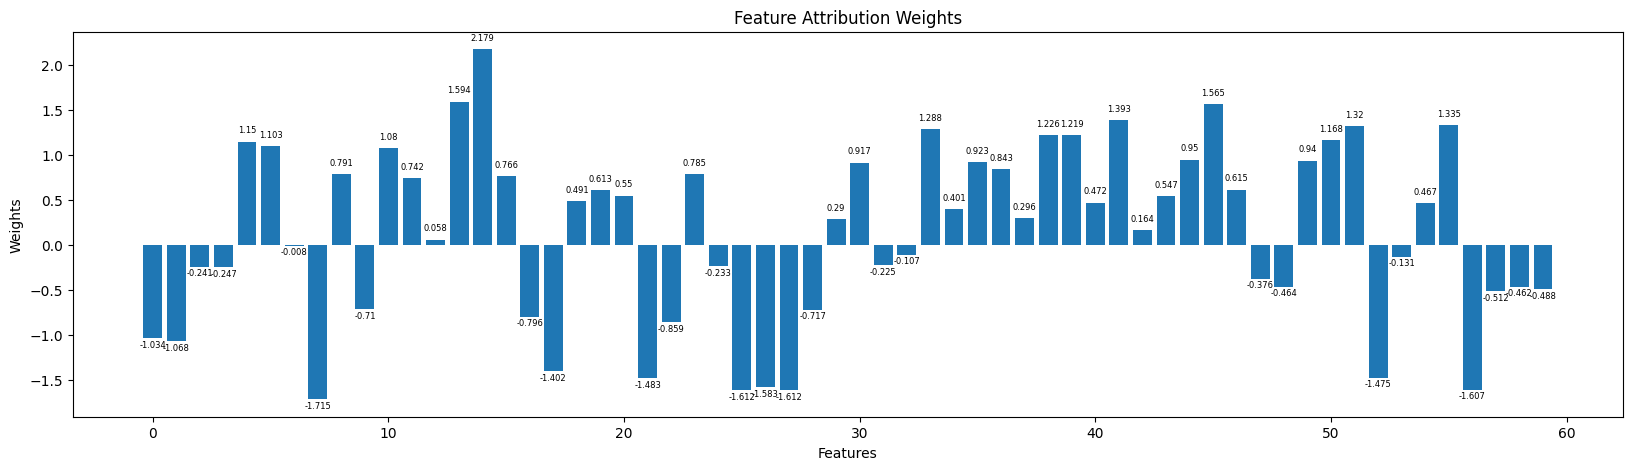

In [245]:
plot_weights(model)

Accuracy, Precision, Recall, F1
[0.6470588235294118, 0.625, 0.8333333333333334, 0.7142857142857143]


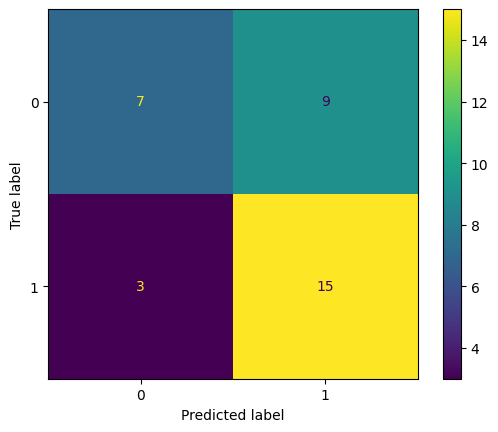

In [246]:
with torch.no_grad():
    evaluate_model(X_train, y_train, X_val, y_val, show_confusion=True)

### Test Set

In [247]:
# reload_imports()
# model.eval()
# evaluate_model(X_train_full, y_train_full, X_test, y_test, show_confusion=True)